Exercise: Build a Denoising Convolutional Autoencoder
Dataset: Devnagari Handwritten Digit Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
data_path = '/content/drive/MyDrive/AI Workshop/Week 4/DevanagariHandwrittenDigitDataset'

train_path = os.path.join(data_path, 'Train')
test_path = os.path.join(data_path, 'Test')

def load_images(folder_path):
    images = []

    for digit in os.listdir(folder_path):
        digit_path = os.path.join(folder_path, digit)

        if os.path.isdir(digit_path):
            for file in os.listdir(digit_path):
                img_path = os.path.join(digit_path, file)

                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((28, 28))
                    img = np.array(img)

                    images.append(img)
                except:
                    continue

    return np.array(images)

In [4]:
x_train = load_images(train_path)
x_test = load_images(test_path)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (17000, 28, 28)
Test shape: (3000, 28, 28)


In [6]:
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# Reshape (VERY IMPORTANT for CNN)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (17000, 28, 28, 1)
Test shape: (3000, 28, 28, 1)


In [5]:
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

#Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

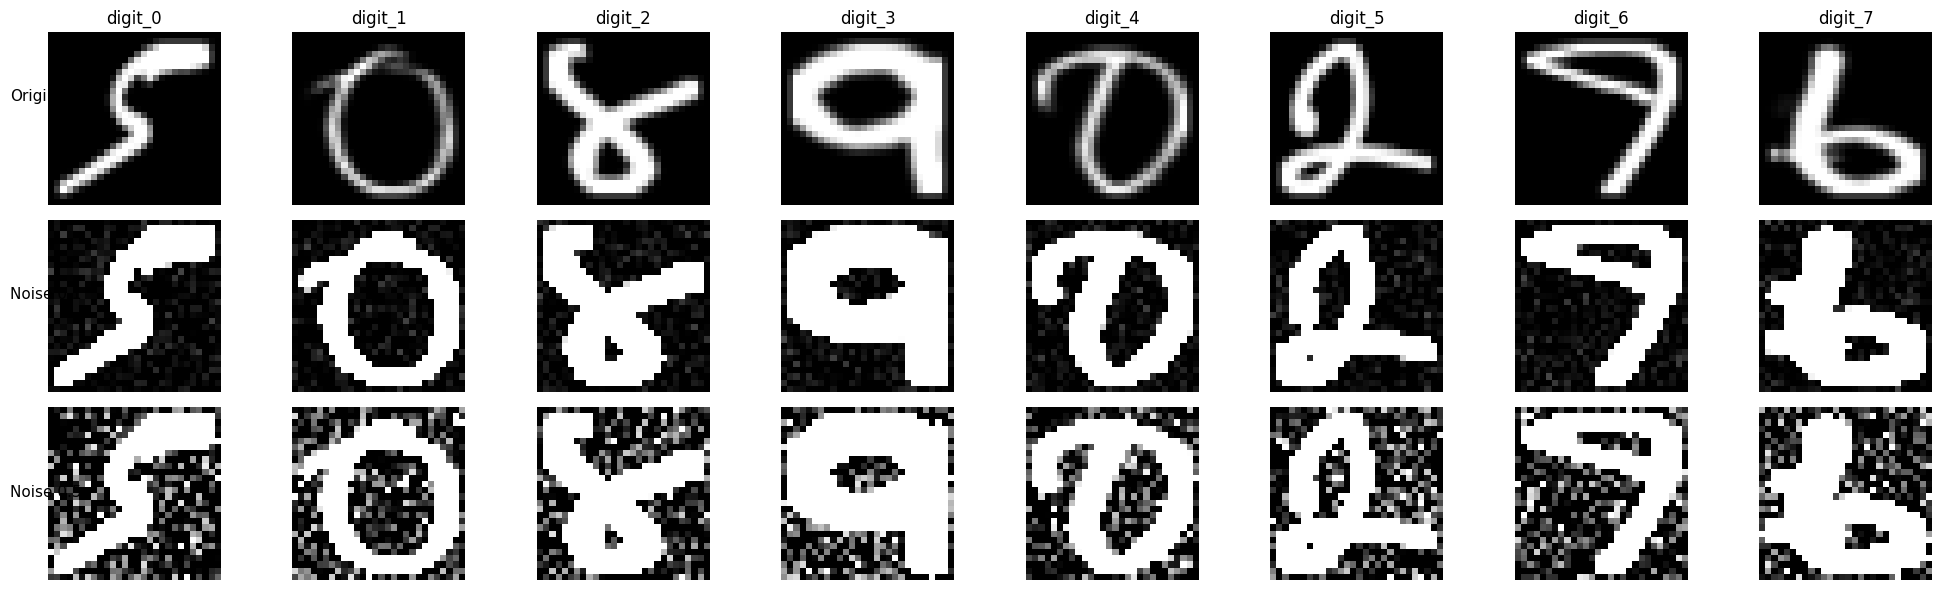

In [14]:
# Get all digit folder names (0,1,2,...9) sorted
digit_folders = sorted(os.listdir(train_path))

# Dictionary to store number of images in each digit folder
images_per_digit = {}

for digit in digit_folders:
    digit_path = os.path.join(train_path, digit)

    # Check if it's actually a folder
    if os.path.isdir(digit_path):

        # Count number of image files in each digit folder
        images_per_digit[digit] = len([
            f for f in os.listdir(digit_path)
            if os.path.isfile(os.path.join(digit_path, f))
        ])

# List to store (digit_label, index in x_train)
digit_indices = []

# Keeps track of cumulative position in x_train
cumulative = 0

for digit in digit_folders:
    if digit in images_per_digit:

        # Only add index if it's within dataset size
        if cumulative < x_train.shape[0]:

            # Store digit and a sample index (cumulative - 1)
            digit_indices.append((digit, cumulative - 1))

        # Move forward by number of images in that digit folder
        cumulative += images_per_digit[digit]

# Number of digits we will display
n_digits = len(digit_indices)

# Create figure for plotting (3 rows: original, low noise, high noise)
plt.figure(figsize=(20, 6))

for col, (label, idx) in enumerate(digit_indices):

    # -------------------------
    # Row 1: Original images
    # -------------------------
    plt.subplot(3, n_digits, col + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"{label}")
    plt.axis('off')

    # -------------------------
    # Row 2: Low noise images
    # -------------------------
    plt.subplot(3, n_digits, col + 1 + n_digits)
    plt.imshow(x_train_noisy_low[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # -------------------------
    # Row 3: High noise images
    # -------------------------
    plt.subplot(3, n_digits, col + 1 + 2 * n_digits)
    plt.imshow(x_train_noisy_high[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

# Add labels on left side of figure
plt.gcf().text(0.01, 0.83, "Original", va='center', fontsize=11)
plt.gcf().text(0.01, 0.50, "Noise 0.1", va='center', fontsize=11)
plt.gcf().text(0.01, 0.17, "Noise 0.5", va='center', fontsize=11)

# Adjust spacing to avoid overlap
plt.tight_layout()

# Show final visualization
plt.show()

In [15]:
def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [16]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.
  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [17]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [18]:
autoencoder = build_autoencoder()
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Training Autoencoder
# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 433ms/step - loss: 0.3024 - val_loss: 0.2089
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 431ms/step - loss: 0.1898 - val_loss: 0.1827
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 438ms/step - loss: 0.1803 - val_loss: 0.1783
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 428ms/step - loss: 0.1765 - val_loss: 0.1753
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 435ms/step - loss: 0.1743 - val_loss: 0.1726
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 429ms/step - loss: 0.1724 - val_loss: 0.1712
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 431ms/step - loss: 0.1708 - val_loss: 0.1707
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 429ms/step - loss: 0.1702 - val_loss: 0.1717
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 427ms/step - loss: 0.1689 - val_loss: 0.1692
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 451ms/step - loss: 0.1678 - val_loss: 0.1682


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


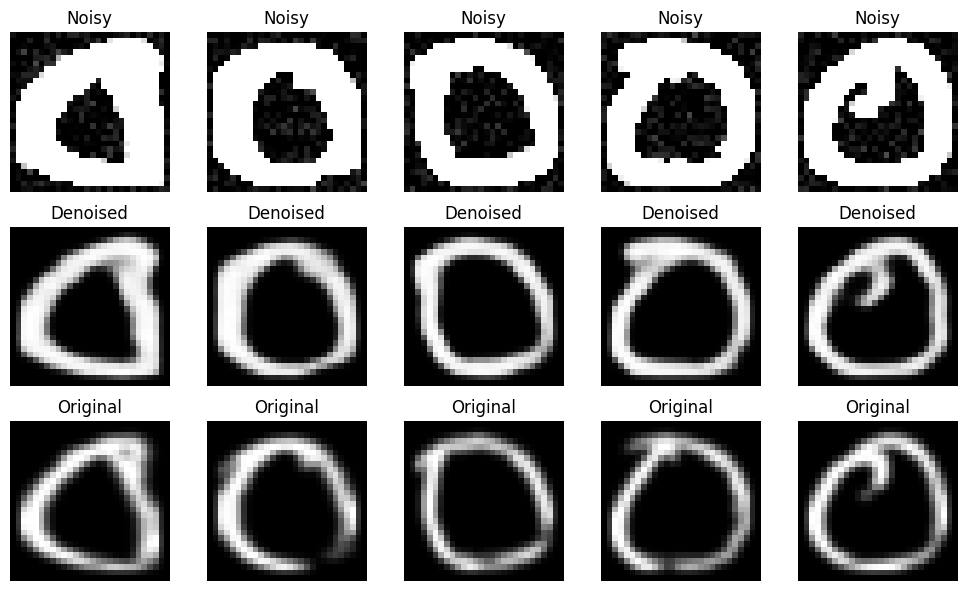

In [21]:
n = 5  # number of samples to display

# Generate denoised images
denoised_imgs = autoencoder.predict(x_test_noisy_high) # Using x_test_noisy_high because the model was trained on high noise

plt.figure(figsize=(10, 6))

for i in range(n):

    # -------------------------
    # Noisy Image
    # -------------------------
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # -------------------------
    # Denoised Image
    # -------------------------
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # -------------------------
    # Original Image
    # -------------------------
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()